# 📈 Task 7: Sales Forecasting

## 1. Problem Statement

**Problem:** Predict future weekly sales for Walmart stores and departments based on historical sales data, store characteristics, and external economic factors.

**Dataset:** [Walmart Sales Forecast (Kaggle)](https://www.kaggle.com/competitions/walmart-recruiting-store-sales-forecasting) — 421,570 weekly sales records across 45 stores and 81 departments from Feb 2010 to Oct 2012, with accompanying store features, economic indicators, and holiday markers.

**Objective:** Build a regression model that forecasts next-period weekly sales using time-based feature engineering (lags, rolling averages, calendar features). Report the model's improvement against a **naive persistence baseline** (predicting past sales values) rather than only against another trained model, and evaluate with MAE/RMSE on a chronological holdout.

## 2. Imports & Setup

In [1]:
%matplotlib inline
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

import gradio as gr

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = "data"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
FEATURES_PATH = os.path.join(DATA_DIR, "features.csv")
STORES_PATH = os.path.join(DATA_DIR, "stores.csv")

TARGET = "Weekly_Sales"
CUTOFF_DATE = pd.Timestamp("2012-07-01")

MODELS_DIR = "models"
ASSETS_DIR = "assets"
for d in (MODELS_DIR, ASSETS_DIR):
    os.makedirs(d, exist_ok=True)

print("Setup complete. Cutoff date for train/test split:", CUTOFF_DATE.date())

Setup complete. Cutoff date for train/test split: 2012-07-01


## 3. Load & Explore Data

In [2]:
train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"])
test = pd.read_csv(TEST_PATH, parse_dates=["Date"])
features = pd.read_csv(FEATURES_PATH, parse_dates=["Date"])
stores = pd.read_csv(STORES_PATH)

print("=== Train ===")
print(f"Shape: {train.shape}")
print(f"Date range: {train['Date'].min().date()} to {train['Date'].max().date()}")
print(f"Stores: {train['Store'].nunique()}, Depts: {train['Dept'].nunique()}")
print()
train.info()
train.head()

=== Train ===
Shape: (421570, 5)
Date range: 2010-02-05 to 2012-10-26
Stores: 45, Depts: 81

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
print("=== Test ===")
print(f"Shape: {test.shape}")
print(f"Date range: {test['Date'].min().date()} to {test['Date'].max().date()}")
print()
print("=== Features ===")
print(f"Shape: {features.shape}")
features.info()
print()
print("=== Stores ===")
print(f"Shape: {stores.shape}")
print(stores.head())
print(f"\nStore types: {stores['Type'].value_counts().to_dict()}")

=== Test ===
Shape: (115064, 4)
Date range: 2012-11-02 to 2013-07-26

=== Features ===
Shape: (8190, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[ns]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-null   float64       
 5   MarkDown2     2921 non-null   float64       
 6   MarkDown3     3613 non-null   float64       
 7   MarkDown4     3464 non-null   float64       
 8   MarkDown5     4050 non-null   float64       
 9   CPI           7605 non-null   float64       
 10  Unemployment  7605 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 712.0 KB

=== Sto

In [4]:
print("=== Train Statistics ===")
print(train.describe())
print(f"\nMissing values in train:")
print(train.isnull().sum())
print(f"\nNegative sales count: {(train[TARGET] < 0).sum()}")
print(f"Zero sales count: {(train[TARGET] == 0).sum()}")

=== Train Statistics ===


               Store           Dept                           Date  \
count  421570.000000  421570.000000                         421570   
mean       22.200546      44.260317  2011-06-18 08:30:31.963375104   
min         1.000000       1.000000            2010-02-05 00:00:00   
25%        11.000000      18.000000            2010-10-08 00:00:00   
50%        22.000000      37.000000            2011-06-17 00:00:00   
75%        33.000000      74.000000            2012-02-24 00:00:00   
max        45.000000      99.000000            2012-10-26 00:00:00   
std        12.785297      30.492054                            NaN   

        Weekly_Sales  
count  421570.000000  
mean    15981.258123  
min     -4988.940000  
25%      2079.650000  
50%      7612.030000  
75%     20205.852500  
max    693099.360000  
std     22711.183519  

Missing values in train:


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Negative sales count: 1285
Zero sales count: 73


In [5]:
print("=== Features Missing Values ===")
print(features.isnull().sum())
print(f"\nMarkDown NAs are concentrated in 2010 (programs not yet active).")
print(f"CPI/Unemployment missing in last {features[features['CPI'].isna()]['Date'].nunique()} weeks (test tail).")

=== Features Missing Values ===
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

MarkDown NAs are concentrated in 2010 (programs not yet active).
CPI/Unemployment missing in last 13 weeks (test tail).


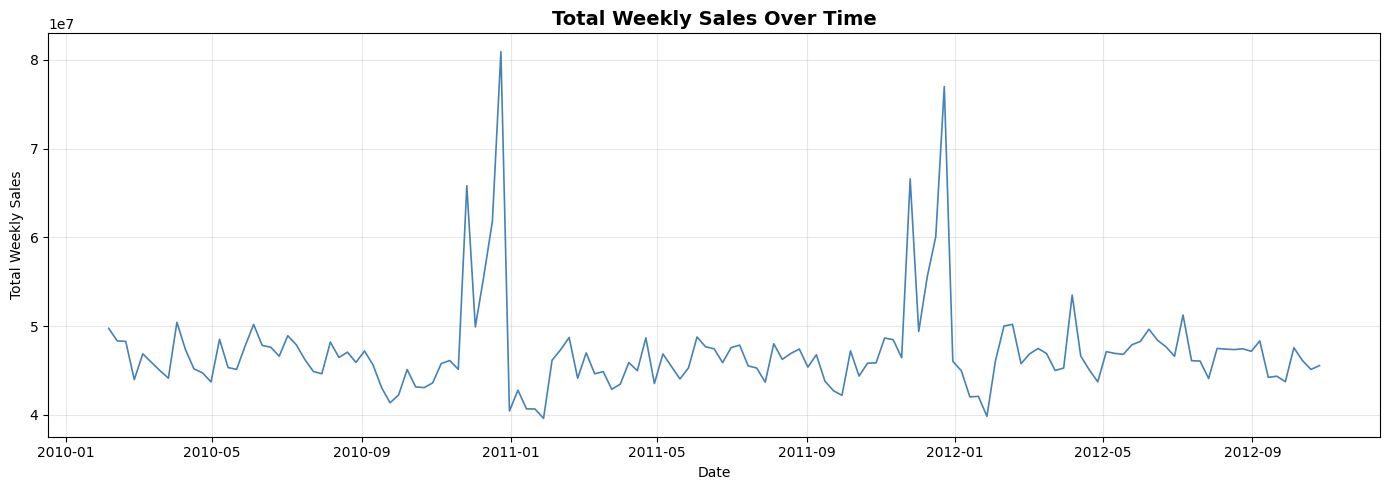

In [6]:
weekly_sales = train.groupby("Date")[TARGET].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_sales["Date"], weekly_sales[TARGET], linewidth=1.2, color="steelblue")
ax.set_title("Total Weekly Sales Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Total Weekly Sales")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "eda_sales_trend.png"), dpi=150)
plt.show()

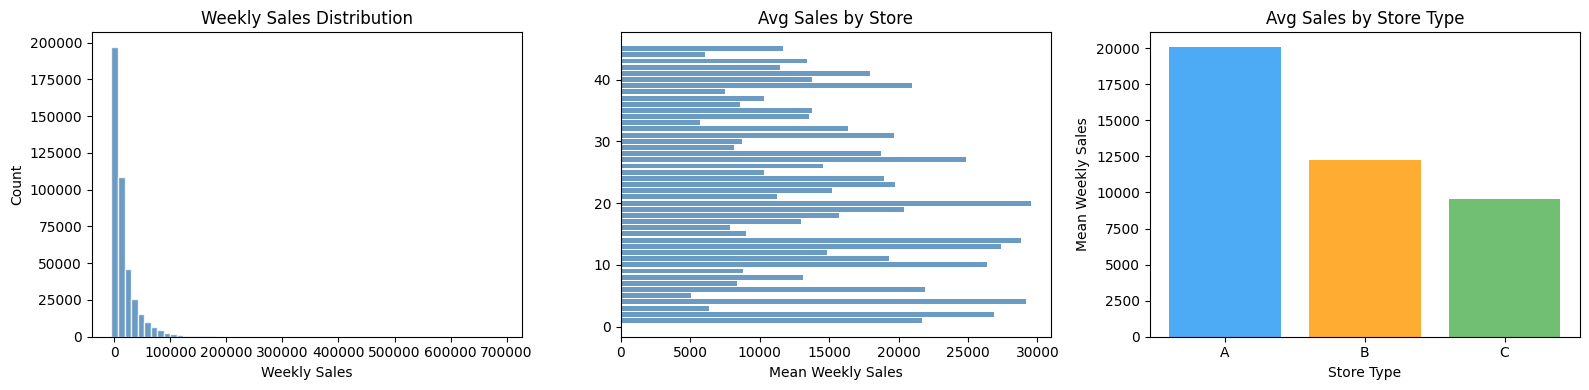

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train[TARGET], bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Weekly Sales Distribution")
axes[0].set_xlabel("Weekly Sales")
axes[0].set_ylabel("Count")

store_sales = train.groupby("Store")[TARGET].mean().sort_values()
axes[1].barh(store_sales.index, store_sales.values, color="steelblue", alpha=0.8)
axes[1].set_title("Avg Sales by Store")
axes[1].set_xlabel("Mean Weekly Sales")

store_type_sales = train.merge(stores, on="Store").groupby("Type")[TARGET].mean()
axes[2].bar(store_type_sales.index, store_type_sales.values, color=["#2196F3", "#FF9800", "#4CAF50"], alpha=0.8)
axes[2].set_title("Avg Sales by Store Type")
axes[2].set_xlabel("Store Type")
axes[2].set_ylabel("Mean Weekly Sales")

plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "eda_sales_dist.png"), dpi=150)
plt.show()

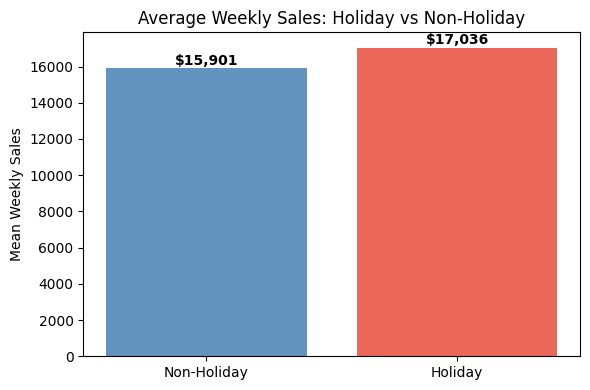

In [8]:
holiday_sales = train.groupby("IsHoliday")[TARGET].mean()
holiday_sales.index = ["Non-Holiday", "Holiday"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(holiday_sales.index, holiday_sales.values, color=["steelblue", "#e74c3c"], alpha=0.85)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"${bar.get_height():,.0f}", ha="center", fontweight="bold")
ax.set_title("Average Weekly Sales: Holiday vs Non-Holiday")
ax.set_ylabel("Mean Weekly Sales")
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "eda_holiday.png"), dpi=150)
plt.show()

## 4. Cleaning & Preprocessing

**Key decisions:**
- **Drop negative Weekly_Sales rows (~1,285):** Negative values represent data-entry errors or full-store returns, not genuine weekly sales. Including them would distort the regression target.
- **Fill MarkDown NAs with 0:** MarkDown columns record promotional dollar amounts. `NaN` means no promotion was active that week — zero is the correct semantic value.
- **Forward-fill then backward-fill CPI/Unemployment:** These are macro-economic indicators that change slowly. The last 13 weeks have missing values (the test tail); forward-fill from the last observed value is appropriate.
- **Drop duplicate `IsHoliday` from features:** Both `train` and `features` carry this column. We keep the one from `train` to avoid duplication after the merge.

In [9]:
merged = train.merge(features.drop(columns=["IsHoliday"]), on=["Store", "Date"], how="left")
merged = merged.merge(stores, on="Store", how="left")

print(f"Merged shape: {merged.shape}")
print(f"Missing values after merge:")
print(merged.isnull().sum()[merged.isnull().sum() > 0])

Merged shape: (421570, 16)
Missing values after merge:
MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64


In [10]:
n_before = len(merged)
merged = merged[merged[TARGET] >= 0].copy()
print(f"Dropped {n_before - len(merged)} rows with negative sales.")

markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
merged[markdown_cols] = merged[markdown_cols].fillna(0)
print(f"Filled MarkDown NAs with 0.")

merged["CPI"] = merged.groupby("Store")["CPI"].transform(lambda x: x.ffill().bfill())
merged["Unemployment"] = merged.groupby("Store")["Unemployment"].transform(lambda x: x.ffill().bfill())
print(f"Forward/backward filled CPI and Unemployment per store.")

type_map = {"A": 0, "B": 1, "C": 2}
merged["StoreType"] = merged["Type"].map(type_map)
merged.drop(columns=["Type"], inplace=True)
print(f"Encoded store type: {type_map}")

print(f"\nRemaining missing values: {merged.isnull().sum().sum()}")
print(f"Clean shape: {merged.shape}")

Dropped 1285 rows with negative sales.
Filled MarkDown NAs with 0.
Forward/backward filled CPI and Unemployment per store.


Encoded store type: {'A': 0, 'B': 1, 'C': 2}

Remaining missing values: 0
Clean shape: (420285, 16)


## 5. Feature Engineering

Time-series forecasting requires **temporal features** that give the model access to seasonality, trends, and recent history. We create:

- **Calendar features:** `day_of_week`, `month`, `week_of_year`, `year` — extracted from the `Date` column.
- **Lag features:** `lag_1`, `lag_2`, `lag_3` — the sales from 1, 2, and 3 weeks prior, **per (Store, Dept)** group. These give the model direct access to recent sales momentum.
- **Rolling averages:** `rolling_4w`, `rolling_8w`, `rolling_13w` — trailing mean sales over 4, 8, and 13 weeks, capturing short-term and quarterly trends.
- **Trend feature:** `days_since_start` — a continuous counter of days since the first observation, encoding the overall upward/downward trend.

All lag and rolling features are computed **within each (Store, Dept) group** to prevent data leakage across stores or departments.

In [11]:
merged = merged.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

merged["day_of_week"] = merged["Date"].dt.dayofweek
merged["month"] = merged["Date"].dt.month
merged["week_of_year"] = merged["Date"].dt.isocalendar().week.astype(int)
merged["year"] = merged["Date"].dt.year

start_date = merged["Date"].min()
merged["days_since_start"] = (merged["Date"] - start_date).dt.days

group_key = ["Store", "Dept"]

merged["lag_1"] = merged.groupby(group_key)[TARGET].shift(1)
merged["lag_2"] = merged.groupby(group_key)[TARGET].shift(2)
merged["lag_3"] = merged.groupby(group_key)[TARGET].shift(3)

merged["rolling_4w"] = merged.groupby(group_key)[TARGET].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
)
merged["rolling_8w"] = merged.groupby(group_key)[TARGET].transform(
    lambda x: x.shift(1).rolling(window=8, min_periods=1).mean()
)
merged["rolling_13w"] = merged.groupby(group_key)[TARGET].transform(
    lambda x: x.shift(1).rolling(window=13, min_periods=1).mean()
)

print(f"Shape after feature engineering: {merged.shape}")
print(f"NaN rows (from lag creation): {merged.isnull().any(axis=1).sum()}")
merged.head()

Shape after feature engineering: (420285, 27)
NaN rows (from lag creation): 9859


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,month,week_of_year,year,days_since_start,lag_1,lag_2,lag_3,rolling_4w,rolling_8w,rolling_13w
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,2,5,2010,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,2,6,2010,7,24924.50,NaN,NaN,24924.500000,24924.500000,24924.500000
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,2,7,2010,14,46039.49,24924.50,NaN,35481.995000,35481.995000,35481.995000
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,2,8,2010,21,41595.55,46039.49,24924.50,37519.846667,37519.846667,37519.846667
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,3,9,2010,28,19403.54,41595.55,46039.49,32990.770000,32990.770000,32990.770000


In [12]:
feature_cols = [
    "Store", "Dept", "IsHoliday", "Temperature", "Fuel_Price",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment", "StoreType", "Size",
    "day_of_week", "month", "week_of_year", "year", "days_since_start",
    "lag_1", "lag_2", "lag_3",
    "rolling_4w", "rolling_8w", "rolling_13w",
]

print(f"Total features: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")

Total features: 25
Feature list: ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'StoreType', 'Size', 'day_of_week', 'month', 'week_of_year', 'year', 'days_since_start', 'lag_1', 'lag_2', 'lag_3', 'rolling_4w', 'rolling_8w', 'rolling_13w']


## 6. Train/Test Split

For time-series forecasting, a **chronological split** is essential — we never shuffle, as future data must never leak into training. The cutoff date is **2012-07-01**: everything before trains, everything on/after tests. This gives 126 training weeks and 17 test weeks.

In [13]:
merged_clean = merged.dropna(subset=["lag_1", "lag_2", "lag_3"]).copy()

train_df = merged_clean[merged_clean["Date"] < CUTOFF_DATE].copy()
test_df = merged_clean[merged_clean["Date"] >= CUTOFF_DATE].copy()

X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_test = test_df[feature_cols]
y_test = test_df[TARGET]

print(f"Train: {X_train.shape[0]} rows ({train_df['Date'].min().date()} to {train_df['Date'].max().date()})")
print(f"Test:  {X_test.shape[0]} rows ({test_df['Date'].min().date()} to {test_df['Date'].max().date()})")
print(f"Train date range strictly before cutoff: {CUTOFF_DATE.date()}")

Train: 360274 rows (2010-02-26 to 2012-06-29)
Test:  50152 rows (2012-07-06 to 2012-10-26)
Train date range strictly before cutoff: 2012-07-01


## 7. Model Training

**Naive baselines (persistence):** a forecaster that "predicts the past" with zero learning. Two references are used:
- **Repeat same week last year** (52-week seasonal persistence) — the natural benchmark here, because Walmart's weekly sales are strongly seasonal (Thanksgiving/Christmas/Easter spikes).
- **Repeat 3 weeks ago** — a short-memory persistence that covers every holdout row.

Any real model must beat these; they define the performance floor.

**Baseline: Linear Regression** — a simple, interpretable model that exercises the same feature set.

**Final Model: XGBoost Regressor** — chosen because:
1. Tree-based models handle non-linear feature interactions (e.g., holiday weeks × store type) without feature engineering.
2. XGBoost is robust to unscaled features and mixed data types.
3. It regularly wins time-series forecasting competitions on structured/tabular data.
4. Built-in regularization (max_depth, learning_rate) mitigates overfitting on noisy sales data.

In [ ]:
# --- Naive persistence baselines (predict past values; no learning) ---
# Repeat same week last year (52-week seasonal persistence), matched by exact
# date offset so any data gaps are handled correctly.
sales_lookup = merged[["Store", "Dept", "Date", TARGET]].rename(columns={TARGET: "seasonal_prior"})
sales_lookup["Date"] = sales_lookup["Date"] + pd.DateOffset(weeks=52)
test_with_seas = test_df[["Store", "Dept", "Date"]].merge(sales_lookup, on=["Store", "Dept", "Date"], how="left")
test_df_naive = test_df.copy()
test_df_naive["seasonal_prior"] = test_with_seas["seasonal_prior"].values

naive_seasonal_mask = test_df_naive["seasonal_prior"].notna().values
seas_pred = test_df_naive.loc[naive_seasonal_mask, "seasonal_prior"]
seas_actual = test_df_naive.loc[naive_seasonal_mask, TARGET]
seas_mae = mean_absolute_error(seas_actual, seas_pred)
seas_rmse = np.sqrt(mean_squared_error(seas_actual, seas_pred))

# Repeat 3 weeks ago (short-memory persistence; covers every test row)
naive3_pred = X_test["lag_3"]
naive3_mae = mean_absolute_error(y_test, naive3_pred)
naive3_rmse = np.sqrt(mean_squared_error(y_test, naive3_pred))

print(f"Naive persistence (same week last year, n={naive_seasonal_mask.sum():,}):  MAE {seas_mae:,.2f} | RMSE {seas_rmse:,.2f}")
print(f"Naive persistence (repeat 3 weeks ago, n={len(y_test):,}):              MAE {naive3_mae:,.2f} | RMSE {naive3_rmse:,.2f}")

# --- Linear Regression (same lag/rolling feature set, for reference) ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
print(f"Linear Regression — MAE: {lr_mae:,.2f} | RMSE: {lr_rmse:,.2f}")

In [15]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f"XGBoost — MAE: {xgb_mae:,.2f} | RMSE: {xgb_rmse:,.2f}")

XGBoost — MAE: 1,360.85 | RMSE: 2,860.95


## 8. Evaluation

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Naive persistence (same week last year)",
        "Naive persistence (repeat 3 weeks ago)",
        "Linear Regression (features)",
        "XGBoost (final)",
    ],
    "MAE": [seas_mae, naive3_mae, lr_mae, xgb_mae],
    "RMSE": [seas_rmse, naive3_rmse, lr_rmse, xgb_rmse],
})
print(results.to_string(index=False))

# Like-for-like improvement vs the seasonal persistence baseline (same rows)
xgb_mae_subset = mean_absolute_error(y_test[naive_seasonal_mask], xgb_preds[naive_seasonal_mask])
xgb_rmse_subset = np.sqrt(mean_squared_error(y_test[naive_seasonal_mask], xgb_preds[naive_seasonal_mask]))

improvement_mae = (seas_mae - xgb_mae_subset) / seas_mae * 100
improvement_rmse = (seas_rmse - xgb_rmse_subset) / seas_rmse * 100
print(f"\nXGBoost beats the persistence floor by {improvement_mae:.1f}% on MAE and {improvement_rmse:.1f}% on RMSE")
print(f"(scored like-for-like on the same {int(naive_seasonal_mask.sum()):,} rows as the seasonal baseline).")

lr_improvement_mae = (lr_mae - xgb_mae) / lr_mae * 100
lr_improvement_rmse = (lr_rmse - xgb_rmse) / lr_rmse * 100
print(f"XGBoost vs Linear Regression: {lr_improvement_mae:.1f}% MAE, {lr_improvement_rmse:.1f}% RMSE (for reference).")

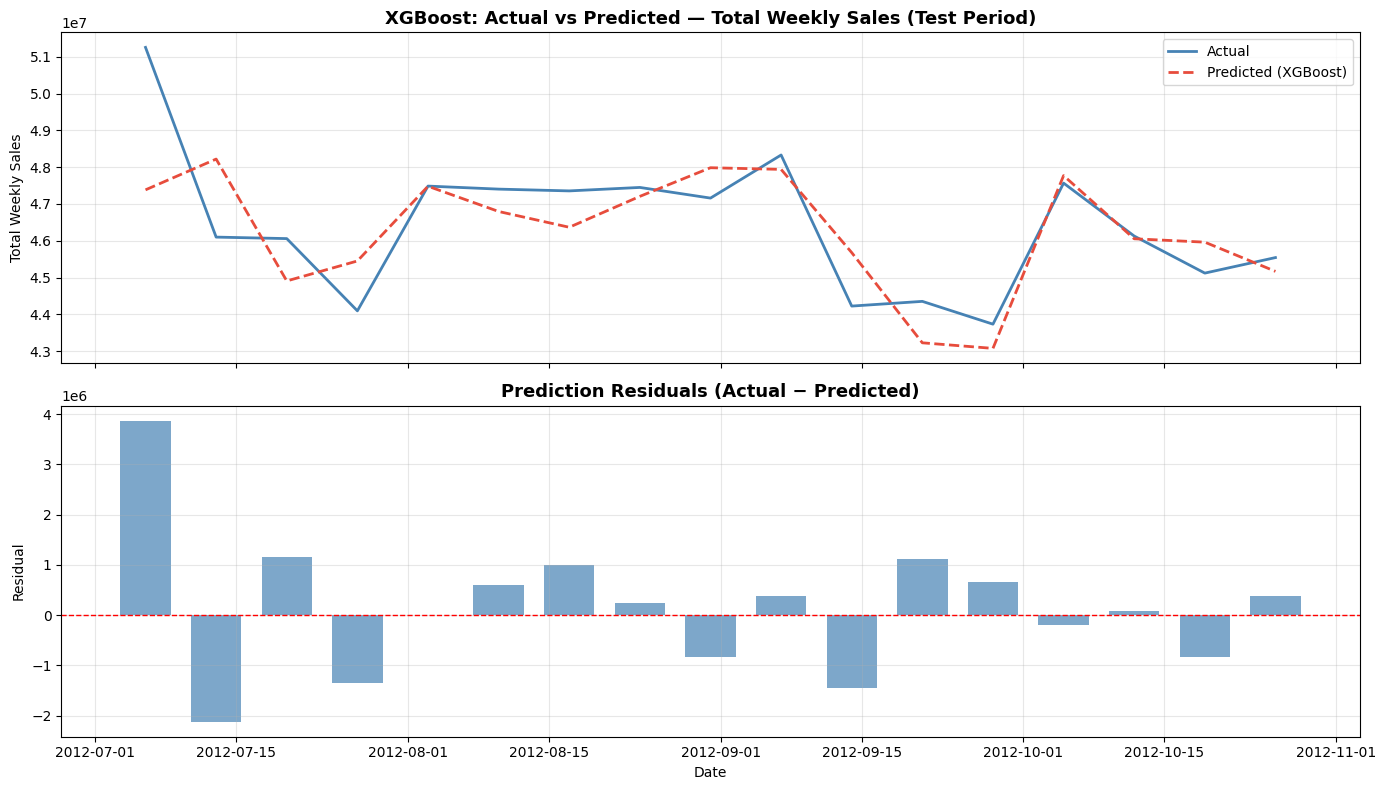

Saved to assets\results.png


In [17]:
test_df_eval = test_df.copy()
test_df_eval["Predicted"] = xgb_preds

weekly_actual = test_df_eval.groupby("Date")[TARGET].sum()
weekly_predicted = test_df_eval.groupby("Date")["Predicted"].sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(weekly_actual.index, weekly_actual.values, label="Actual", color="steelblue", linewidth=2)
axes[0].plot(weekly_predicted.index, weekly_predicted.values, label="Predicted (XGBoost)", color="#e74c3c", linewidth=2, linestyle="--")
axes[0].set_title("XGBoost: Actual vs Predicted — Total Weekly Sales (Test Period)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Total Weekly Sales")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = weekly_actual.values - weekly_predicted.values
axes[1].bar(weekly_actual.index, residuals, color="steelblue", alpha=0.7, width=5)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Prediction Residuals (Actual − Predicted)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Residual")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "results.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {os.path.join(ASSETS_DIR, 'results.png')}")

## 9. Bonus Work

- **Seasonal decomposition** — decompose the aggregated sales time series into trend, seasonal, and residual components using `statsmodels`.
- **Time-aware cross-validation** — use `TimeSeriesSplit` with 5 folds to validate the XGBoost model without future data leakage.

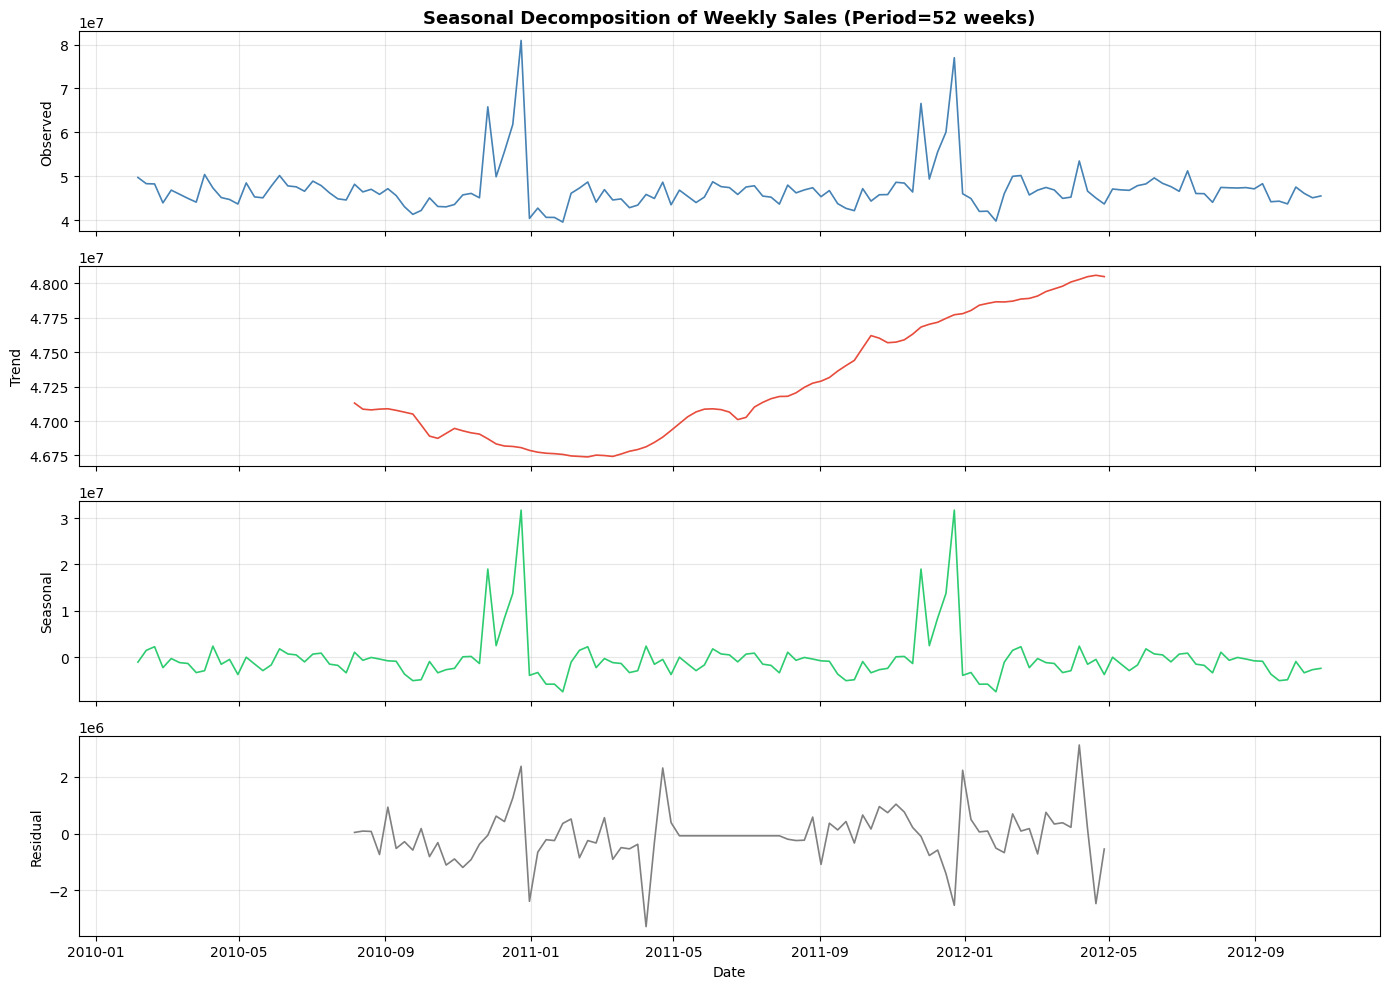

Seasonal decomposition saved.


In [18]:
ts_weekly = train.groupby("Date")[TARGET].sum().asfreq("W-FRI")
ts_weekly = ts_weekly.ffill()

decomposition = seasonal_decompose(ts_weekly, model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [(decomposition.observed, "Observed", "steelblue"),
              (decomposition.trend, "Trend", "#e74c3c"),
              (decomposition.seasonal, "Seasonal", "#2ecc71"),
              (decomposition.resid, "Residual", "gray")]

for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.2)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Seasonal Decomposition of Weekly Sales (Period=52 weeks)", fontsize=13, fontweight="bold")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "seasonal_decomposition.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Seasonal decomposition saved.")

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Scope the cross-validation to the PRE-CUTOFF period only. The holdout
# horizon (>= 2012-07-01) must never appear inside a CV fold: if it did, the
# 50,152 holdout rows would be validated in-fold (73.3% of the last fold) and
# then re-used as the final test period, double-counting them. TimeSeriesSplit
# therefore runs on the 360,274 pre-cutoff rows, so the last validation fold
# ends 2012-06-29 — one week before the holdout begins.
merged_cv = merged_clean[merged_clean["Date"] < CUTOFF_DATE].sort_values("Date").reset_index(drop=True).copy()

X_cv = merged_cv[feature_cols]
y_cv = merged_cv[TARGET]

tscv = TimeSeriesSplit(n_splits=5)
cv_maes = []
cv_rmses = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv)):
    X_fold_train, X_fold_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
    y_fold_train, y_fold_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]
    val_dates = merged_cv.iloc[val_idx]["Date"]
    assert val_dates.max() < CUTOFF_DATE, "CV folds must stay strictly pre-cutoff"

    xgb_cv = XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    xgb_cv.fit(X_fold_train, y_fold_train)
    preds = xgb_cv.predict(X_fold_val)

    fold_mae = mean_absolute_error(y_fold_val, preds)
    fold_rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
    cv_maes.append(fold_mae)
    cv_rmses.append(fold_rmse)
    print(f"Fold {fold+1}: MAE={fold_mae:,.2f}  RMSE={fold_rmse:,.2f}  (val {val_dates.min().date()}..{val_dates.max().date()})")

print(f"\nCV MAE:  {np.mean(cv_maes):,.2f} (+/- {np.std(cv_maes):,.2f})")
print(f"CV RMSE: {np.mean(cv_rmses):,.2f} (+/- {np.std(cv_rmses):,.2f})")
print("Note: CV averages over 2010-2012 pre-cutoff windows that include high-variance")
print("holiday periods (e.g. fold 2 spans Thanksgiving/Christmas) while the single")
print("17-week summer holdout (Jul-Oct 2012) is scored with the full 126-week")
print("training history — so holdout < CV is expected and not a contradiction.")

## 10. Save Artifacts

In [20]:
joblib.dump(xgb_model, os.path.join(MODELS_DIR, "best_model.pkl"))
print(f"Saved best_model.pkl ({os.path.getsize(os.path.join(MODELS_DIR, 'best_model.pkl')) / 1024 / 1024:.1f} MB)")

joblib.dump(feature_cols, os.path.join(MODELS_DIR, "feature_names.pkl"))
print(f"Saved feature_names.pkl")

feature_config = {
    "feature_cols": feature_cols,
    "target": TARGET,
    "lag_windows": [1, 2, 3],
    "rolling_windows": [4, 8, 13],
    "calendar_features": ["day_of_week", "month", "week_of_year", "year", "days_since_start"],
    "cutoff_date": str(CUTOFF_DATE.date()),
    "start_date": str(start_date.date()),
    "type_map": type_map,
    "store_type_col": "StoreType",
}
joblib.dump(feature_config, os.path.join(MODELS_DIR, "feature_config.pkl"))
print(f"Saved feature_config.pkl")

for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(os.path.join(MODELS_DIR, f))
    print(f"  {f}: {size / 1024 / 1024:.1f} MB")

Saved best_model.pkl (2.2 MB)
Saved feature_names.pkl
Saved feature_config.pkl
  best_model.pkl: 2.2 MB
  feature_config.pkl: 0.0 MB
  feature_names.pkl: 0.0 MB


## 11. Gradio Interface

In [ ]:
model_artifact = joblib.load(os.path.join(MODELS_DIR, "best_model.pkl"))
feat_config = joblib.load(os.path.join(MODELS_DIR, "feature_config.pkl"))
feat_names = joblib.load(os.path.join(MODELS_DIR, "feature_names.pkl"))
start_dt = pd.Timestamp(feat_config["start_date"])

store_list = sorted(merged_clean["Store"].unique().tolist())
dept_list = sorted(merged_clean["Dept"].unique().tolist())

# Real historical sales per (Store, Dept) — pre-fills the app so lag/rolling
# features reproduce exactly what training saw.
hist_map = {}
for (store, dept), grp in train.sort_values("Date").groupby(["Store", "Dept"]):
    hist_map[(store, dept)] = (grp["Date"].tolist(), grp["Weekly_Sales"].tolist())

def build_recent_history(store, dept, target_date, n=13):
    dates, sales = hist_map.get((store, dept), ([], []))
    target = pd.Timestamp(target_date)
    prior = [s for d, s in zip(dates, sales) if pd.Timestamp(d) < target]
    return prior[-n:]

def parse_history(value):
    return [float(x.strip().replace(",", "")) for x in str(value).split(",") if x.strip()]

def predict_sales(store, dept, is_holiday, temperature, fuel_price,
                  markdown1, markdown2, markdown3, markdown4, markdown5,
                  cpi, unemployment, store_type, size,
                  history_text, forecast_date):
    store_type_code = int(store_type.split("(")[1].rstrip(")"))

    # The data are Friday-dated weekly records: snap to the Friday of the ISO week.
    target = pd.Timestamp(str(forecast_date)[:10])
    iso_year, iso_week, _ = target.isocalendar()
    friday = pd.Timestamp.fromisocalendar(iso_year, iso_week, 5)
    day_of_week = friday.dayofweek          # always Friday == 4 in this dataset
    month = friday.month
    week_of_year = friday.isocalendar().week
    year = friday.year
    days_since = (friday - start_dt).days

    hist = parse_history(history_text)
    lag_1, lag_2, lag_3 = hist[-1], hist[-2], hist[-3]
    rolling_4w = float(np.mean(hist[-4:]))
    rolling_8w = float(np.mean(hist[-8:]))
    rolling_13w = float(np.mean(hist[-13:]))

    feature_values = [
        store, dept, int(is_holiday), temperature, fuel_price,
        markdown1, markdown2, markdown3, markdown4, markdown5,
        cpi, unemployment, store_type_code, size,
        day_of_week, month, week_of_year, year, days_since,
        lag_1, lag_2, lag_3, rolling_4w, rolling_8w, rolling_13w,
    ]

    assert len(feature_values) == len(feat_names), (
        f"Feature count mismatch: {len(feature_values)} vs {len(feat_names)}"
    )
    input_df = pd.DataFrame([feature_values], columns=feat_names)
    prediction = model_artifact.predict(input_df)[0]

    recent_weeks = [hist[-3], hist[-2], hist[-1], prediction]
    labels = ["W-3", "W-2", "W-1", "Forecast"]
    colors = ["steelblue", "steelblue", "steelblue", "#e74c3c"]

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(labels, recent_weeks, color=colors, alpha=0.85, edgecolor="white")
    for i, v in enumerate(recent_weeks):
        ax.text(i, v + max(recent_weeks)*0.01, f"${v:,.0f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title("Recent Trend + Forecast", fontweight="bold")
    ax.set_ylabel("Weekly Sales")
    ax.grid(True, alpha=0.2, axis="y")
    plt.tight_layout()

    return prediction, fig

demo = gr.Interface(
    fn=predict_sales,
    inputs=[
        gr.Dropdown(store_list, value=store_list[0], label="Store"),
        gr.Dropdown(dept_list, value=dept_list[0], label="Department"),
        gr.Checkbox(label="Is Holiday Week?"),
        gr.Number(value=60.0, label="Temperature (°F)"),
        gr.Number(value=3.5, label="Fuel Price"),
        gr.Number(value=0, label="MarkDown1"),
        gr.Number(value=0, label="MarkDown2"),
        gr.Number(value=0, label="MarkDown3"),
        gr.Number(value=0, label="MarkDown4"),
        gr.Number(value=0, label="MarkDown5"),
        gr.Number(value=220.0, label="CPI"),
        gr.Number(value=7.5, label="Unemployment"),
        gr.Dropdown(["A (0)", "B (1)", "C (2)"], value="A (0)", label="Store Type"),
        gr.Number(value=150000, label="Store Size (sq ft)"),
        gr.Textbox(
            value=", ".join(f"{v:.0f}" for v in build_recent_history(store_list[0], dept_list[0], "2012-09-21")),
            label="Last 13 weekly sales (most recent LAST, comma separated)",
        ),
        gr.DateTime(value="2012-09-21", include_time=False, type="string", label="Forecast week (choose the Friday)"),
    ],
    outputs=[
        gr.Number(label="Forecasted Weekly Sales"),
        gr.Plot(label="Recent Trend + Forecast"),
    ],
    title="Task 7: Sales Forecasting — Live Prediction",
    description="Predict weekly Walmart sales for a given store/department using XGBoost.",
)

try:
    demo.launch(share=True, prevent_thread_lock=True)
    print("Demo launched — use the printed share link for assets/gradio_demo.png.")
except Exception as exc:
    print("Public share link unavailable:", exc)
    demo.launch(prevent_thread_lock=True)